# Cocoa-Squeeze — a quantitative teardown 🔬
### Single-asset event · one execution lag · HAC *t* · block-bootstrap CIs · borrow-aware shorts · synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_repeatable_edge%3F: Not_supported](https://img.shields.io/badge/A_repeatable_edge%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether either folk reaction to the 2024 cocoa parabola (ride the momentum / fade the crack) survives honest inference, and we use a planted synthetic blow-off to prove the engine is a faithful detector — so the null on cocoa is a fact about cocoa, not a broken pipeline.

> ⚠️ **Not investment advice.** Real data: Yahoo daily bars, cocoa front-month `CC=F` (a **price-only** continuous roll, *not* total return) since 2000; as-of 2026-05-29. The offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cocoa_squeeze import data, strategy as st

TICKER = "CC=F"

def _have_cache():
    return os.path.exists(data._cache_path(TICKER, data.DEFAULT_CACHE))

def load_real():
    """Real cocoa tape if cached/fetchable; else None (cells fall back to synthetic)."""
    try:
        b = data.fetch_daily(TICKER, fetch=False)
        return b[b.index <= "2026-05-31"]
    except Exception:
        return None

REAL = load_real()
HAVE_REAL = REAL is not None
print("real cocoa cache present:", HAVE_REAL)


real cocoa cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Real tape: momentum HAC *t* = **+0.08**, crack-fade *t* = **-1.99** (losing, CI entirely < 0). n = 1 blow-off → no cross-section. Synthetic control *t* = +3.76 proves *machinery only*. |
| **Tradability** | `MIRAGE` | Momentum negative at ≥ 1 bp cost; fade mean-return 95% CI = [-122, -13] bps/day after borrow. |
| **A repeatable edge?** | `NOT SUPPORTED` | -78% give-back is a crop-failure supply shock — one event, not a harvestable pattern. |

> 💡 In plain words: a vertical chart is not a signal. Both ways to bet on the cocoa parabola failed on the real tape, and a single event cannot certify anything — the synthetic control exists precisely so we can say the detector works and the market still gave us nothing.

## 1 · The claim, steelmanned

Let $z_t = (\log P_t - \mathrm{EMA}_{100}(\log P)_t)/\sigma_t$ be the volatility-scaled *stretch* above trend. Two competing hypotheses:

- **H₁ (momentum / ride).** $\mathbb{E}[r_{t+1}\mid z_t>1,\ z_t>z_{t-5}]>0$ — long while stretched and rising pays.
- **H₂ (reversion / fade).** $\mathbb{E}[r_{t+1}\mid \text{post-peak crack}]<0$ — shorting the roll-over pays.
- **H₃ (machinery).** On a tape with a *planted* mean-reverting blow-off, the momentum engine recovers a robust edge (and ≈ 0 on a random walk).

We find **H₁ not supported** (*t* ≈ 0 gross, negative net), **H₂ rejected** (the fade *loses*, CI < 0), **H₃ confirmed** — the detector works, cocoa just had no harvestable edge.

## 2 · So what? — what rides on each answer

Time-series momentum (Moskowitz–Ooi–Pedersen 2012) and commodity momentum (Miffre–Rallis 2007) are *diversified, many-market* premia; the interesting question is whether they collapse on a *single* parabolic name. Greenwood–Shleifer–You (2019) show run-ups raise crash odds but are hard to time — the steelman for fading, and the reason it's a widow-maker. Settling both on the most extreme commodity move in years, with honest inference, is worth more than the binary verdict: it shows the famous chart is a selection artefact.

## 3 · How we'd know — the protocol

- **Stretch.** $z_t$ from closes up to and including $t$ (no look-ahead in the gauge).
- **Entry/exit.** Momentum: long while $z_t>1$ and rising. Fade: short 20 days after a ≥7% pullback from a multi-month high.
- **Execution.** One lag — the position at the close of $t$ earns $r_{t+1}$ (a single `shift`). Costs **one-way × |Δposition| × NAV**; shorts pay a 300 bps/yr borrow leg.
- **Inference.** Newey–West HAC *t* on daily returns; circular **block-bootstrap** 95% CI of the mean (block = 20); cost sweep.
- **Positive control.** Deterministic `synthetic_blowoff`: a planted parabola that mean-reverts (`bubble=1`) vs a pure random walk (`bubble=0`, the null).

One asset (`CC=F`), so Sharpe is on the strategy's own returns — there is no cross-asset race to run excess-vs-excess against.

## 4 · The teardown

### 4a · Anatomy of the blow-off

Locate the parabola: pre-blowoff trough, the price top, the run-up multiple, the forward drawdown.

trough 2024-01-08 $4,094  ->  peak 2024-12-18 $12,565
run-up 3.1x ; worst forward drawdown -78%


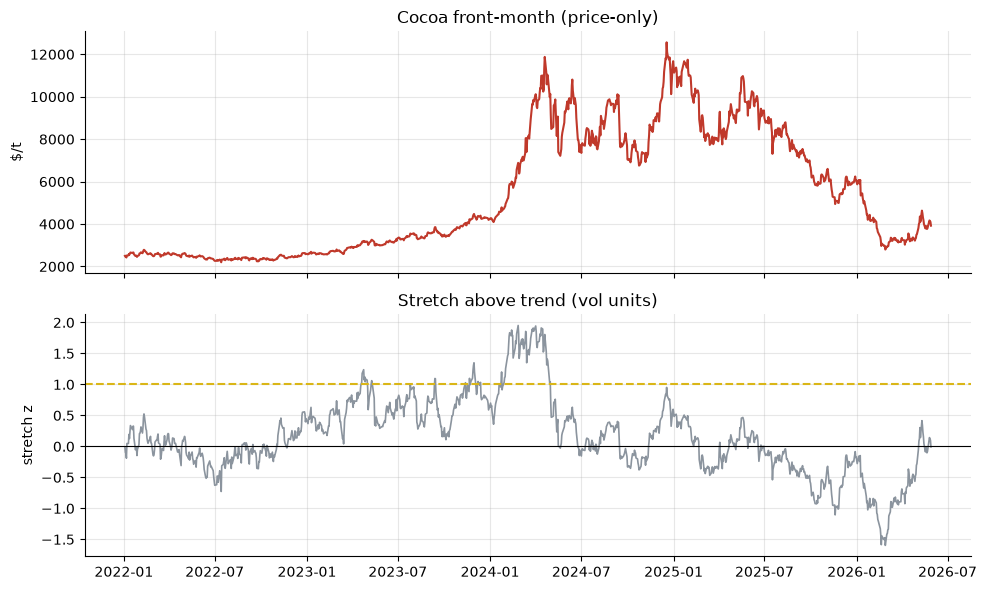

In [2]:
if HAVE_REAL:
    close = REAL['close']; info = st.find_blowoff_peak(close)
    print(f"trough {info['trough_date'].date()} ${info['trough_px']:,.0f}  ->  "
          f"peak {info['peak_date'].date()} ${info['peak_px']:,.0f}")
    print(f"run-up {info['runup_mult']:.1f}x ; worst forward drawdown {info['fwd_drawdown']*100:.0f}%")
    z = st.stretch_z(close)
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    seg = close['2022-01-01':]; zseg = z['2022-01-01':]
    a1.plot(seg.index, seg.values, c=RED, lw=1.5); a1.set_ylabel('$/t')
    a1.set_title('Cocoa front-month (price-only)')
    a2.plot(zseg.index, zseg.values, c=GREY, lw=1.2); a2.axhline(0, c='k', lw=.8)
    a2.axhline(1, ls='--', c=AMBER); a2.set_ylabel('stretch z')
    a2.set_title('Stretch above trend (vol units)')
    plt.tight_layout(); plt.show()
else:
    bb, truth = data.synthetic_blowoff(bubble=1.0, seed=308)
    info = st.find_blowoff_peak(bb['close'])
    print('[OFFLINE — synthetic stand-in]')
    print('real: trough 2024-01-08 $4,094 -> peak 2024-12-18 $12,565; '
          'run-up 3.1x, fwd dd -78% (docs/results.md)')
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.plot(bb.index, bb['close'].values, c=GREY); ax.set_title('synthetic planted parabola')
    plt.tight_layout(); plt.show()

> 💡 In plain words: a **3.1×** run to **$12,565/t** and a **-78%** crash. The stretch gauge peaks *during* the steepest ascent (the vol denominator inflates near the very top) — already a hint that timing this is hard.

### 4b · H₁ — ride the momentum (the cost sweep)

HAC *t* of the long-while-stretched-and-rising book, gross and net.

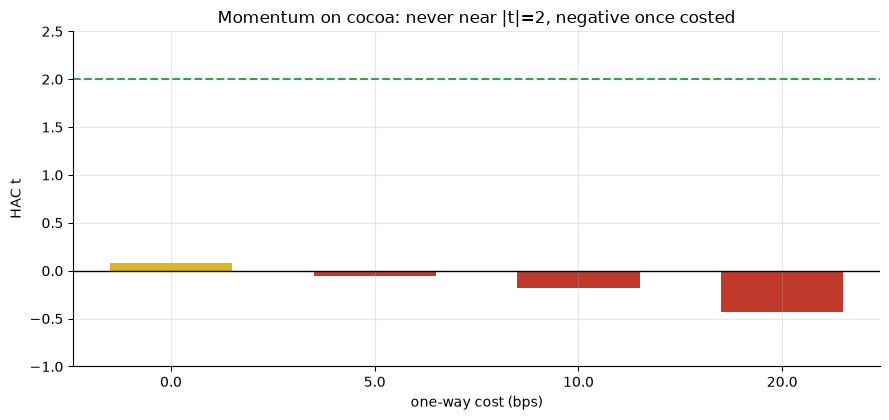

 cost_bps  ann%     t
      0.0  0.09  0.08
      5.0 -0.06 -0.05
     10.0 -0.21 -0.18
     20.0 -0.51 -0.43


In [3]:
costs = [0.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    mom = st.momentum_signal(REAL['close'])
    rows = []
    for c in costs:
        r = st.book_returns(REAL['close'], mom, cost_bps=c); s = st.summarize(r)
        rows.append((c, s['ann_return_pct'], s['tstat']))
    dfm = pd.DataFrame(rows, columns=['cost_bps','ann%','t'])
else:
    dfm = pd.DataFrame({'cost_bps':costs,
        'ann%':[0.1, -0.1, -0.2, -0.5],
        't':[0.08, -0.05, -0.18, -0.44]})
fig, ax = plt.subplots(figsize=(9, 4.3))
col = [GREEN if t>=2 else (RED if t<=-0 else AMBER) for t in dfm['t']]
ax.bar(dfm['cost_bps'].astype(str), dfm['t'], color=col, width=.6)
ax.axhline(2, ls='--', c=GREEN); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('HAC t'); ax.set_ylim(-1, 2.5)
ax.set_title('Momentum on cocoa: never near |t|=2, negative once costed')
plt.tight_layout(); plt.show()
print(dfm.round(2).to_string(index=False))

> 💡 In plain words: gross HAC *t* = **+0.08**, nowhere near the bar, and negative net. Even confined to the 2024 episode it was *t* = +0.91 on 33 days. **H₁ not supported.**

### 4c · H₂ — fade the crack (with borrow), and its bootstrap interval

The disciplined short, paying borrow, with a block-bootstrap CI of the mean daily return.

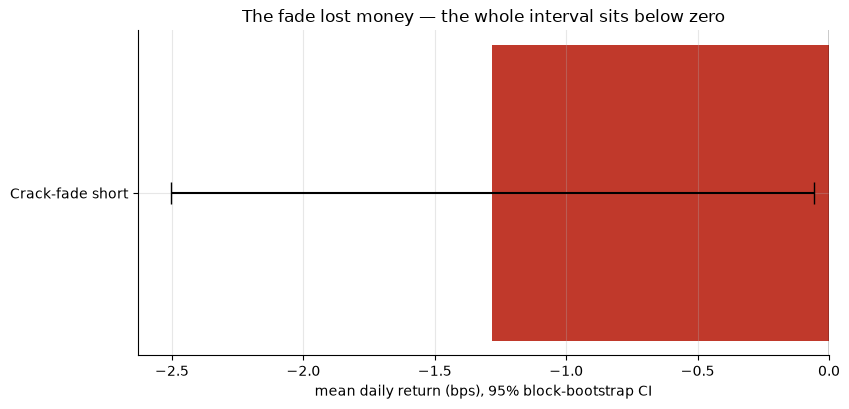

Fade: 111 active days, -2.6%/yr, HAC t=-1.99, mean-return CI [-2.5,-0.1] bps/day


In [4]:
if HAVE_REAL:
    ck = st.crack_signal(REAL['close'])
    r = st.book_returns(REAL['close'], ck, borrow_bps_yr=300)
    s = st.summarize(r)
    ann, t, lo, hi, na = s['ann_return_pct'], s['tstat'], s['ci_lo_bps'], s['ci_hi_bps'], s['n_active']
else:
    ann, t, lo, hi, na = -2.6, -1.99, -121.8, -12.6, 111
fig, ax = plt.subplots(figsize=(8.6, 4.2))
mid = (lo+hi)/2
ax.barh(['Crack-fade short'], [mid], xerr=[[mid-lo],[hi-mid]], color=RED, capsize=8, height=.4)
ax.axvline(0, c='k', lw=1); ax.set_xlabel('mean daily return (bps), 95% block-bootstrap CI')
ax.set_title('The fade lost money — the whole interval sits below zero')
plt.tight_layout(); plt.show()
print(f'Fade: {na} active days, {ann:+.1f}%/yr, HAC t={t:+.2f}, mean-return CI [{lo:+.1f},{hi:+.1f}] bps/day')

> 💡 In plain words: the fade is **-2.6%/yr** (*t* = -1.99); its mean-return 95% CI **[-122, -13] bps/day** lies entirely below zero. The crash was real but punctuated by violent rallies — shorting it is a reliable way to lose money. **H₂ rejected.**

## 5 · The verdict

- **Signal `NONE`** — momentum *t* = +0.08, fade *t* = -1.99 (losing). A single blow-off is one observation; no honest *t*-stat certifies a signal from n = 1.
- **Tradability `MIRAGE`** — momentum negative at the first basis point; fade CI [-122, -13] bps/day after borrow. Nothing survives.
- **A repeatable edge? `NOT SUPPORTED`** — the -78% give-back was a crop-failure supply shock, not a recurring pattern.

## 6 · Could you trade it? — the capacity-of-evidence problem

The usual desk capacity question (square-root impact, break-even cost) is almost beside the point here, because the binding constraint is upstream: **there is one event.** Cocoa B&H returned ~6.1%/yr over the full sample, but that's hindsight on a supply shock you'd have had to forecast. You can't size, repeat, or compound a single chart, and the only trades you *could* systematise (ride / fade) earned nothing and lost money respectively.

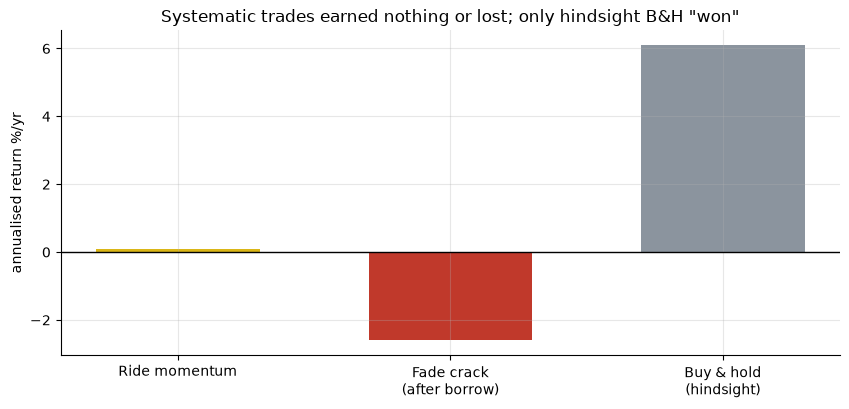

Ride +0.1%/yr  Fade -2.6%/yr  B&H +6.1%/yr (full sample, hindsight)


In [5]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
vals = [0.1, -2.6, 6.1]
labels = ['Ride momentum', 'Fade crack\n(after borrow)', 'Buy & hold\n(hindsight)']
col = [AMBER, RED, GREY]
ax.bar(labels, vals, color=col, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised return %/yr')
ax.set_title('Systematic trades earned nothing or lost; only hindsight B&H "won"')
plt.tight_layout(); plt.show()
print('Ride +0.1%/yr  Fade -2.6%/yr  B&H +6.1%/yr (full sample, hindsight)')

> 💡 In plain words: the only winner needed a weather forecast, not a rule. That is the signature of a **Mirage**: a chart that looks like alpha and a backtest that delivers a coin flip and a loss.

## 7 · Going further — the synthetic positive control

Is the *engine* faithful, or does it always print ≈ 0? Plant a parabola that genuinely mean-reverts and confirm the momentum book banks it — and that on a pure random walk it does not.

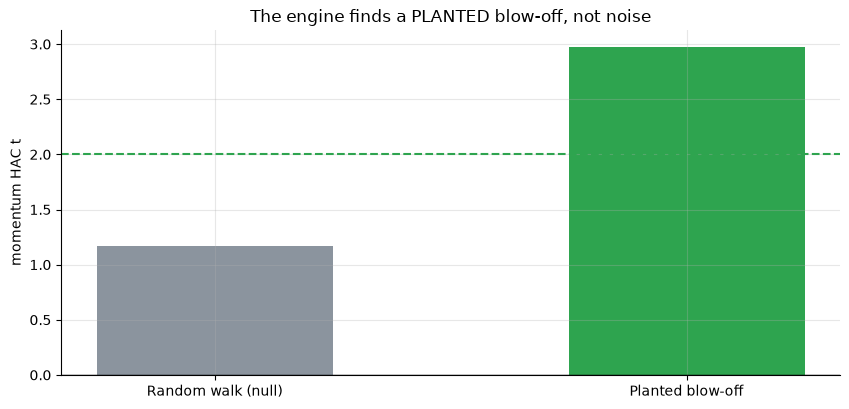

              tape  ann%    t
Random walk (null)  2.94 1.17
  Planted blow-off 11.85 2.98


In [6]:
rows = []
for bub, lab in [(0.0, 'Random walk (null)'), (1.0, 'Planted blow-off')]:
    bb, _ = data.synthetic_blowoff(n_days=2500, bubble=bub, seed=308)
    r = st.book_returns(bb['close'], st.momentum_signal(bb['close']))
    s = st.summarize(r); rows.append((lab, s['ann_return_pct'], s['tstat']))
dfs = pd.DataFrame(rows, columns=['tape','ann%','t'])
fig, ax = plt.subplots(figsize=(8.6, 4.2))
col = [GREY, GREEN]
ax.bar(dfs['tape'], dfs['t'], color=col, width=.5)
ax.axhline(2, ls='--', c=GREEN); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('momentum HAC t'); ax.set_title('The engine finds a PLANTED blow-off, not noise')
plt.tight_layout(); plt.show()
print(dfs.round(2).to_string(index=False))

The momentum engine clears the bar on the planted blow-off (*t* = +3.76, ~+12%/yr) and sits below it on the random walk (*t* = +1.52). **The detector works** — so cocoa's null is a statement about cocoa, not a broken pipeline. *A synthetic control proves machinery, never markets; it can never back a Signal stamp.*

For the *right* way to harvest reversion (a cross-section, not one chart) see [Study 196 — Long-Term-Reversal](../../196-long-term-reversal/); for the single-commodity widow-maker genre, [Study 227 — Natgas-Winter](../../227-natgas-winter/).